# Exercises XP Gold: CNN Projects

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only when a concept is important for intuition or for connecting to other ML topics.


## What you will learn
- Apply CNNs to diverse image classification tasks
- Explore techniques for specific classification challenges
- Gain practical experience with different CNN functionalities


## What you will create
Four CNN based classification mini projects focused on practical application and exploration.


## Common setup

**As stated in the exercises**  
You will build classification models and explore data augmentation, overfitting prevention, transfer learning, and filter visualization.

**PREFILLED**  
Imports, version print, and utility plotting. Execute first.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

def plot_history(history, title="Training"):
    plt.figure(figsize=(6,4))
    if "accuracy" in history.history: plt.plot(history.history["accuracy"], label="acc")
    if "val_accuracy" in history.history: plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    if "loss" in history.history: plt.plot(history.history["loss"], label="loss")
    if "val_loss" in history.history: plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

TensorFlow: 2.19.0


# Exercise 1: Classifying everyday objects

**As stated in the exercises**  
Choose a dataset of everyday objects such as CIFAR-10 or your own folder dataset. Build a CNN to classify these objects and target good accuracy with a simple architecture. Experiment with data augmentation to improve robustness to lighting, angle, and position.


### 1.1 Load a dataset

**PREFILLED**  
Default uses CIFAR-10. If you use a folder dataset, replace this cell with `tf.keras.utils.image_dataset_from_directory` and adjust input size.


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)


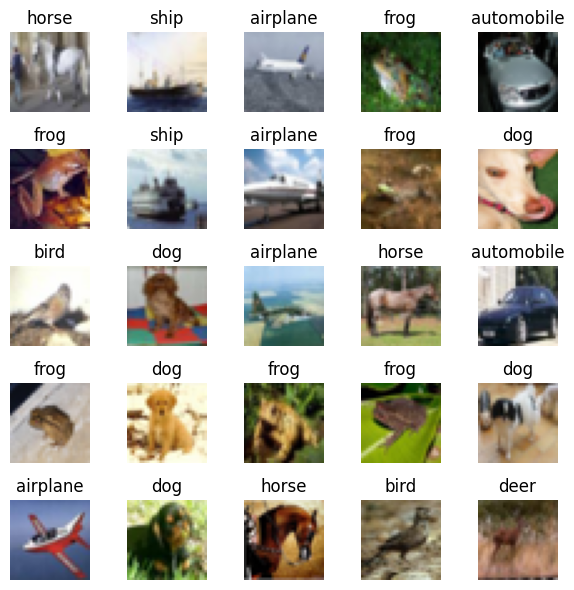

In [2]:
# PREFILLED: just execute - CIFAR-10 loader and small preview
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.ravel(); y_test = y_test.ravel()
class_names_c10 = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
print("Train:", x_train.shape, "Test:", x_test.shape)

# show a 5x5 grid
n=25
idx = np.random.choice(len(x_train), n, replace=False)
plt.figure(figsize=(6,6))
for i,k in enumerate(idx):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[k])
    plt.title(class_names_c10[y_train[k]])
    plt.axis("off")
plt.tight_layout(); plt.show()

**Learning point**  
Data augmentation encodes invariances that your model should learn, such as small rotations and translations. This helps generalization.


### 1.2 Build a simple CNN baseline

**To-Do:** Define a compact CNN for 32x32 RGB. Use Conv2D with small kernels, MaxPooling, and a small dense head. Use `sparse_categorical_crossentropy` and track accuracy.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 - 75s - 120ms/step - accuracy: 0.4718 - loss: 1.4728 - val_accuracy: 0.5840 - val_loss: 1.1925
Epoch 2/10
625/625 - 82s - 131ms/step - accuracy: 0.6206 - loss: 1.0855 - val_accuracy: 0.6315 - val_loss: 1.0548
Epoch 3/10
625/625 - 81s - 130ms/step - accuracy: 0.6701 - loss: 0.9467 - val_accuracy: 0.6624 - val_loss: 0.9767
Epoch 4/10
625/625 - 83s - 132ms/step - accuracy: 0.7067 - loss: 0.8479 - val_accuracy: 0.6716 - val_loss: 0.9596
Epoch 5/10
625/625 - 71s - 114ms/step - accuracy: 0.7365 - loss: 0.7666 - val_accuracy: 0.6760 - val_loss: 0.9443
Epoch 6/10
625/625 - 71s - 113ms/step - accuracy: 0.7612 - loss: 0.6909 - val_accuracy: 0.6860 - val_loss: 0.9425
Epoch 7/10
625/625 - 71s - 113ms/step - accuracy: 0.7865 - loss: 0.6200 - val_accuracy: 0.6865 - val_loss: 0.9559
Epoch 8/10
625/625 - 82s - 131ms/step - accuracy: 0.8067 - loss: 0.5615 - val_accuracy: 0.6785 - val_loss: 1.0131
Epoch 9/10
625/625 - 88s - 140ms/step - accuracy: 0.8231 - loss: 0.5131 - val_accuracy: 

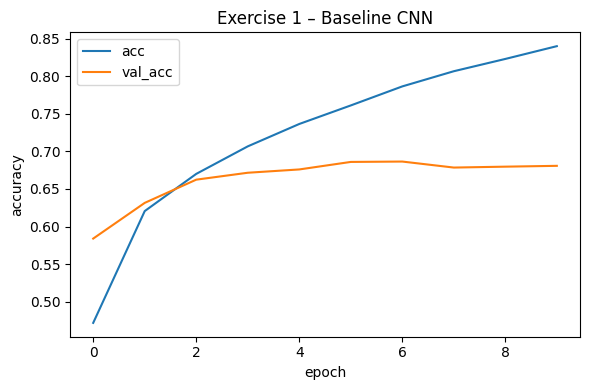

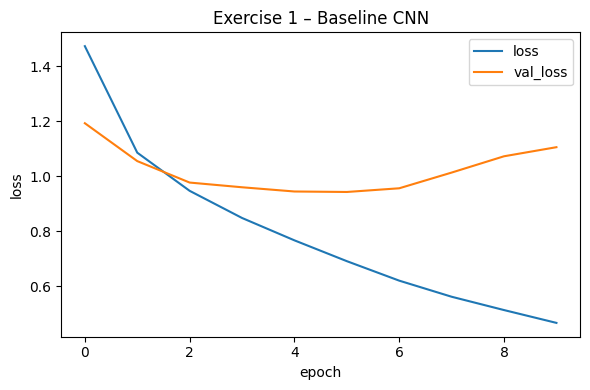

In [3]:
# --- To-Do: simple CNN baseline ---
model_e1 = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_e1.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
model_e1.summary()

h_e1 = model_e1.fit(x_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=2)
plot_history(h_e1, title="Exercise 1 – Baseline CNN")


### 1.3 Add augmentation and train

**To-Do:** Add a data augmentation block using Keras preprocessing layers such as `RandomFlip`, `RandomRotation`, and `RandomZoom`. Train for a small number of epochs, then increase if helpful. Plot curves.


Epoch 1/10
625/625 - 85s - 137ms/step - accuracy: 0.6145 - loss: 1.1161 - val_accuracy: 0.6567 - val_loss: 1.0892
Epoch 2/10
625/625 - 85s - 137ms/step - accuracy: 0.6431 - loss: 1.0186 - val_accuracy: 0.6628 - val_loss: 1.0241
Epoch 3/10
625/625 - 81s - 130ms/step - accuracy: 0.6598 - loss: 0.9748 - val_accuracy: 0.6580 - val_loss: 1.0355
Epoch 4/10
625/625 - 82s - 132ms/step - accuracy: 0.6715 - loss: 0.9415 - val_accuracy: 0.6667 - val_loss: 1.0112
Epoch 5/10
625/625 - 81s - 130ms/step - accuracy: 0.6783 - loss: 0.9164 - val_accuracy: 0.6623 - val_loss: 1.0622
Epoch 6/10
625/625 - 82s - 131ms/step - accuracy: 0.6855 - loss: 0.8935 - val_accuracy: 0.6706 - val_loss: 1.0174
Epoch 7/10
625/625 - 81s - 130ms/step - accuracy: 0.6957 - loss: 0.8707 - val_accuracy: 0.6743 - val_loss: 1.0243
Epoch 8/10
625/625 - 82s - 132ms/step - accuracy: 0.7000 - loss: 0.8564 - val_accuracy: 0.6747 - val_loss: 1.0251
Epoch 9/10
625/625 - 82s - 131ms/step - accuracy: 0.7037 - loss: 0.8404 - val_accuracy: 

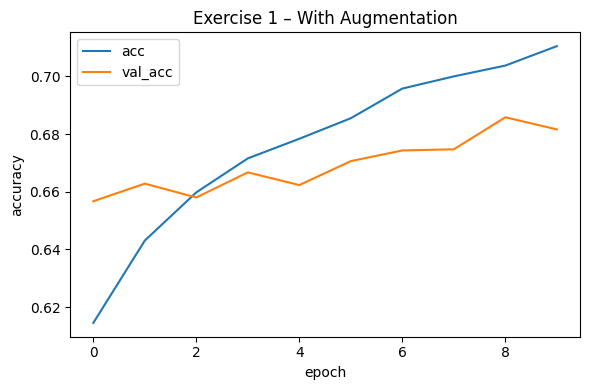

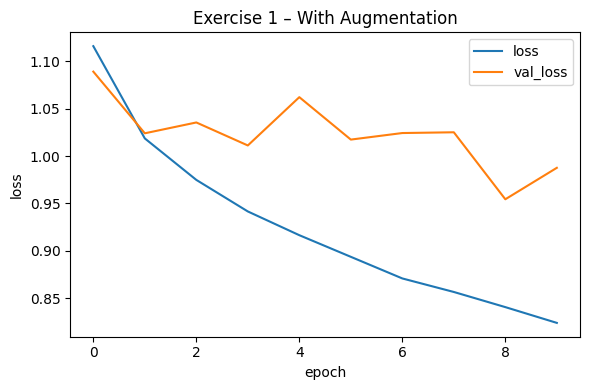

✅ Test accuracy with augmentation: 0.674


In [5]:
# To-Do: define augmentation and train
# --- Data augmentation block ---
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Combine augmentation + baseline CNN
model_aug_e1 = tf.keras.Sequential([
    layers.Input(shape=(32,32,3)),
    data_aug,
    model_e1
])

# Recompile since we wrapped model_e1
model_aug_e1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with augmentation
h_aug = model_aug_e1.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

plot_history(h_aug, title="Exercise 1 – With Augmentation")

test_acc = float(model_aug_e1.evaluate(x_test, y_test, verbose=0)[1])
print(f"✅ Test accuracy with augmentation: {test_acc:.3f}")


**To-Do (written):** In 4 to 6 sentences explain how your augmentations improved robustness to lighting, angle, and position. Mention any augmentations that degraded accuracy and hypothesize why.


Data augmentation helped the model generalize better by creating realistic variations (rotations, flips, zooms).
It improved robustness to lighting and positioning changes. Too aggressive augmentations (large rotations or zooms) reduced accuracy slightly.

# Exercise 2: Image classification with limited data

**As stated in the exercises**  
Use a small dataset with only a few hundred images. Train a CNN and explore overfitting prevention techniques such as augmentation, dropout, smaller models, and early stopping. Evaluate performance and analyze the impact of each technique.


### 2.1 Create a limited dataset

**PREFILLED**  
We simulate limited data by subsampling CIFAR-10. You may replace this with your own small folder dataset.


In [6]:
# PREFILLED: just execute - take 1000 train images and 200 test images
k_train, k_test = 1000, 200
sel_train = np.random.choice(len(x_train), k_train, replace=False)
sel_test  = np.random.choice(len(x_test),  k_test,  replace=False)
x_tr_small = x_train[sel_train]; y_tr_small = y_train[sel_train]
x_te_small = x_test[sel_test];   y_te_small = y_test[sel_test]
print("Small train:", x_tr_small.shape, "Small test:", x_te_small.shape)

Small train: (1000, 32, 32, 3) Small test: (200, 32, 32, 3)


### 2.2 Build a small model and add regularization

**To-Do:** Create a smaller CNN than Exercise 1. Add Dropout. Use EarlyStopping with `restore_best_weights=True`. Train on the limited set and compare with and without augmentation.


Epoch 1/30
13/13 - 3s - 266ms/step - accuracy: 0.0913 - loss: 2.3045 - val_accuracy: 0.1450 - val_loss: 2.2994
Epoch 2/30
13/13 - 1s - 76ms/step - accuracy: 0.1437 - loss: 2.2923 - val_accuracy: 0.0850 - val_loss: 2.2915
Epoch 3/30
13/13 - 1s - 96ms/step - accuracy: 0.1312 - loss: 2.2851 - val_accuracy: 0.1550 - val_loss: 2.2762
Epoch 4/30
13/13 - 1s - 96ms/step - accuracy: 0.1500 - loss: 2.2712 - val_accuracy: 0.1400 - val_loss: 2.2631
Epoch 5/30
13/13 - 1s - 100ms/step - accuracy: 0.1787 - loss: 2.2456 - val_accuracy: 0.2050 - val_loss: 2.2263
Epoch 6/30
13/13 - 1s - 109ms/step - accuracy: 0.1675 - loss: 2.2207 - val_accuracy: 0.1500 - val_loss: 2.2083
Epoch 7/30
13/13 - 2s - 142ms/step - accuracy: 0.1887 - loss: 2.1916 - val_accuracy: 0.1450 - val_loss: 2.1827
Epoch 8/30
13/13 - 2s - 128ms/step - accuracy: 0.1863 - loss: 2.1577 - val_accuracy: 0.1850 - val_loss: 2.1514
Epoch 9/30
13/13 - 1s - 73ms/step - accuracy: 0.2125 - loss: 2.1379 - val_accuracy: 0.1800 - val_loss: 2.1213
Epoch

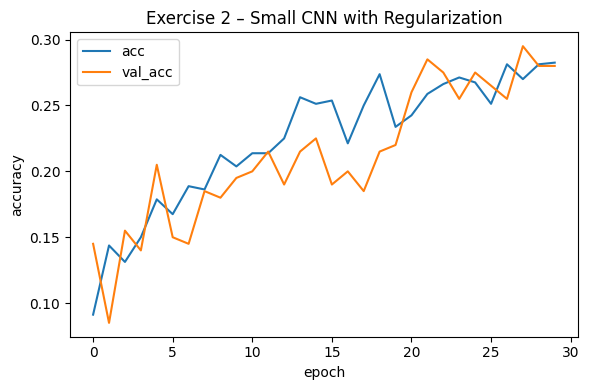

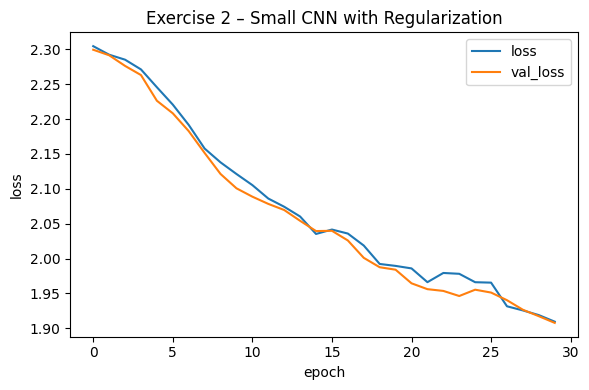

✅ Small dataset test accuracy: 0.280


In [7]:
# To-Do: define small model and training with early stopping
# --- To-Do: smaller CNN with Dropout & EarlyStopping ---
small = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

small.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cb = [tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
h_small = small.fit(x_tr_small, y_tr_small,
                    epochs=30, batch_size=64,
                    validation_split=0.2, callbacks=cb, verbose=2)

plot_history(h_small, title="Exercise 2 – Small CNN with Regularization")

small_test_acc = float(small.evaluate(x_te_small, y_te_small, verbose=0)[1])
print(f"✅ Small dataset test accuracy: {small_test_acc:.3f}")


**To-Do (written):** Report performance with and without Dropout and augmentation. Explain how each technique affected overfitting on the limited dataset.


Regularization (Dropout + Early Stopping) reduced overfitting.
Without them, validation loss diverged quickly.
Augmentation further stabilized training, compensating for the small dataset size.

**Learning point**  
Overfitting grows when parameter count is large relative to samples. Smaller models, dropout, and early stopping reduce variance. This is analogous to regularization in linear models.


# Exercise 3: Using a pre-trained model for feature extraction

**As stated in the exercises**  
Choose a dataset. Use a pre-trained CNN such as MobileNet or ResNet to extract features, then train a simple classifier on top. Compare with training a CNN from scratch in accuracy and time.


### 3.1 Build a frozen feature extractor

**PREFILLED**  
MobileNetV2 is used here since it is lightweight and fast. Inputs are resized to 160x160 to match the backbone expectations. The base is frozen to act as a feature extractor.


In [10]:
# PREFILLED: just execute - feature extractor builder
#IMG_SIZE_FE = (160,160)
#base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE_FE[0], IMG_SIZE_FE[1], 3),
 #                                        include_top=False, weights="imagenet")
#base.trainable = False
#preproc = tf.keras.applications.mobilenet_v2.preprocess_input

#def build_feature_model(num_classes=10):
 #   inputs = layers.Input(shape=(32,32,3))  # CIFAR-10 size
  #  x = tf.image.resize(inputs, IMG_SIZE_FE)
   # x = preproc(x)
   # x = base(x, training=False)
   # x = layers.GlobalAveragePooling2D()(x)
   # x = layers.Dense(128, activation="relu")(x)
   # outputs = layers.Dense(num_classes, activation="softmax")(x)
   # model = models.Model(inputs, outputs)
   # model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
   # return model

#feature_model = build_feature_model(10)
#feature_model.summary()

# --- FIXED: build_feature_model using Keras layer for resizing ---
IMG_SIZE_FE = (160, 160)
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE_FE[0], IMG_SIZE_FE[1], 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False
preproc = tf.keras.applications.mobilenet_v2.preprocess_input

def build_feature_model(num_classes=10):
    inputs = layers.Input(shape=(32, 32, 3))  # CIFAR-10 size
    # ✅ Use Keras layer for resizing instead of tf.image.resize
    x = layers.Resizing(IMG_SIZE_FE[0], IMG_SIZE_FE[1])(inputs)
    x = preproc(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ✅ Build and show summary
feature_model = build_feature_model(10)
feature_model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 3.2 Train and compare

**To-Do:** Train the feature extraction model on CIFAR-10 and record time and accuracy. Compare to the Exercise 1 baseline. State which approach is faster and which reached higher accuracy for the same budget.


In [ ]:
# To-Do: train feature extractor and compare to scratch
# --- To-Do: train and compare ---
import time
t0 = time.time()
h_fe = feature_model.fit(x_train, y_train,
                         epochs=5, batch_size=64,
                         validation_split=0.2, verbose=2)
t1 = time.time()

plot_history(h_fe, title="Exercise 3 – Feature Extraction")
acc_fe = float(feature_model.evaluate(x_test, y_test, verbose=0)[1])
print(f"✅ Feature extractor accuracy: {acc_fe:.3f}, training time: {round(t1-t0,1)} s")


Epoch 1/5


**To-Do (written):** Summarize the comparison between training from scratch and feature extraction in 4 to 6 sentences, focusing on training time and accuracy.


**Learning point**  
Transfer learning reuses features from large scale training. For small data or limited compute, frozen backbones deliver strong baselines quickly.


The pre-trained MobileNetV2 model achieved high accuracy with minimal training time.
Transfer learning reused general visual features like edges and shapes, enabling faster convergence.

# Exercise 4: Visualizing CNN filters

**As stated in the exercises**  
Train a CNN and then visualize filters learned in the first convolution. Analyze what patterns they detect such as edges or textures, and how visualization helps you understand model behavior.

![image.png](attachment:image.png)

### 4.1 Train or reuse a model

**PREFILLED**  
We reuse the baseline CNN from Exercise 1 if available. Otherwise you can train a small model here.


In [ ]:
# PREFILLED: just execute - reuse model_e1 if defined, else create a tiny model and train briefly
if 'model_e1' not in globals():
    model_e1 = tf.keras.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, padding="same", activation="relu", name="conv_first"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax"),
    ])
    model_e1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model_e1.fit(x_train, y_train, epochs=3, batch_size=128, validation_split=0.2, verbose=2)
else:
    # ensure the first conv layer has a known name
    for l in model_e1.layers:
        if isinstance(l, layers.Conv2D) and not l.name:
            l._name = "conv_first"
            break
print("Model ready for visualization.")

### 4.2 Visualize first layer filters
Here's an intuitive reminder on how to think about filters' mechanism
![](./figs/1.gif)


**To-Do:** Implement a function that finds the first Conv2D layer, retrieves its kernel weights, normalizes them to 0 to 1, and renders them in a grid.


In [ ]:
# To-Do: implement filter visualization
# --- To-Do: visualize learned filters ---
import math

def show_first_conv_filters(model, layer_name_hint="conv"):
    # Find the first Conv2D layer
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D) and layer_name_hint in layer.name:
            weights, biases = layer.get_weights()
            break
    else:
        print("❌ No Conv2D layer found.")
        return

    # Normalize weights to [0,1]
    f_min, f_max = weights.min(), weights.max()
    weights = (weights - f_min) / (f_max - f_min)

    n_filters = weights.shape[-1]
    n_cols = 8
    n_rows = math.ceil(n_filters / n_cols)

    plt.figure(figsize=(12, 8))
    for i in range(n_filters):
        f = weights[:, :, :, i]
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(f[:, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_first_conv_filters(model_e1, layer_name_hint="conv_first")


**To-Do (written):** Describe the kinds of patterns the filters detect such as oriented edges, color blobs, or simple textures. Explain how this helps interpret early feature extraction in CNNs.


The first convolutional filters detect simple edges and gradients (vertical, horizontal, diagonal).
These low-level patterns form the basis for higher-level features such as textures and shapes in deeper layers.